In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


Loss summary:


,file,N,method,q10,mean,q90
0,NV_20d_LinQuad_N50.csv,50,NF-GMM,53.282,160.406,314.498
1,NV_20d_LinQuad_N50.csv,50,Non-NF-GMM,38.698,159.448,306.120
2,NV_20d_LinQuad_N50.csv,50,ResDRO,86.651,192.064,337.304
3,NV_20d_LinQuad_N50.csv,50,RNW,178.753,234.931,293.519
4,NV_20d_LinQuad_N50.csv,50,LDR,102.599,281.934,653.420
5,NV_20d_LinQuad_N50.csv,50,NN-DR,79.780,168.362,267.252
6,NV_20d_LinQuad_N100.csv,100,NF-GMM,28.535,133.568,261.308
7,NV_20d_LinQuad_N100.csv,100,Non-NF-GMM,29.414,122.810,244.716
8,NV_20d_LinQuad_N100.csv,100,ResDRO,95.553,184.617,301.145
9,NV_20d_LinQuad_N100.csv,100,RNW,175.894,238.851,296.181


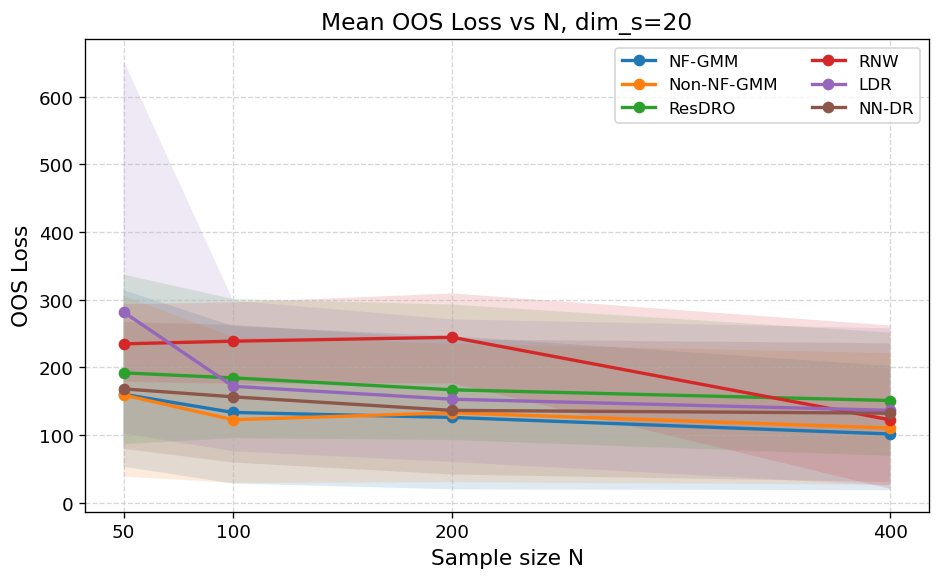

In [2]:
base_dir = Path("Results")
dim_s = 20
N_list = [50, 100, 200, 400]

files = [f"NV_{dim_s}d_LinQuad_N{N}.csv" for N in N_list]

loss_columns = [
    "loss_NF_GMM",
    "loss_nonNF_GMM",
    "loss_ResDRO",
    "loss_RNW",
    "loss_LDR",
    "loss_NN_DR"
]

time_columns = [
    "time_NF_GMM",
    "time_NF_gmm",
    "time_nonNF_GMM",
    "time_nonNF_gmm",
    "time_ResDRO",
    "time_RNW",
    "time_LDR",
    "time_NN_DR"
]

label_map = {
    "loss_NF_GMM": "NF-GMM",
    "loss_nonNF_GMM": "Non-NF-GMM",
    "loss_ResDRO": "ResDRO",
    "loss_RNW": "RNW",
    "loss_LDR": "LDR",
    "loss_NN_DR": "NN-DR",

    "time_NF_GMM": "NF-GMM",
    "time_NF_gmm": "NF-GMM",
    "time_nonNF_GMM": "Non-NF-GMM",
    "time_nonNF_gmm": "Non-NF-GMM",
    "time_ResDRO": "ResDRO",
    "time_RNW": "RNW",
    "time_LDR": "LDR",
    "time_NN_DR": "NN-DR"
}

method_order = [
    "NF-GMM",
    "Non-NF-GMM",
    "ResDRO",
    "RNW",
    "LDR",
    "NN-DR"
]

loss_rows = []
time_rows = []

for fname in files:
    fpath = base_dir / fname

    if not fpath.exists():
        print(f"File not found, skipping: {fpath}")
        continue

    df = pd.read_csv(fpath)

    N_match = re.search(r"_N(\d+)", fname)
    N_value = int(N_match.group(1)) if N_match else None

    if "Trial" in df.columns:
        avg_df = df[df["Trial"].astype(str) == "AVG"].copy()
        df_no_avg = df[df["Trial"].astype(str) != "AVG"].copy()
    else:
        avg_df = pd.DataFrame()
        df_no_avg = df.copy()

    loss_cols_exist = [c for c in loss_columns if c in df_no_avg.columns]

    for col in loss_cols_exist:
        loss_rows.append({
            "file": fname,
            "N": N_value,
            "method": label_map.get(col, col),
            "q10": pd.to_numeric(df_no_avg[col], errors="coerce").quantile(0.1),
            "mean": pd.to_numeric(df_no_avg[col], errors="coerce").mean(),
            "q90": pd.to_numeric(df_no_avg[col], errors="coerce").quantile(0.9)
        })

    time_cols_exist = [c for c in time_columns if c in df.columns]

    for col in time_cols_exist:
        method_name = label_map.get(col, col)

        if len(avg_df) > 0 and col in avg_df.columns:
            mean_time = pd.to_numeric(avg_df[col], errors="coerce").iloc[0]
        else:
            mean_time = pd.to_numeric(df_no_avg[col], errors="coerce").mean()

        time_rows.append({
            "file": fname,
            "N": N_value,
            "method": method_name,
            "mean_time_sec": mean_time
        })

loss_summary = pd.DataFrame(loss_rows)
comp_time_summary = pd.DataFrame(time_rows)

if len(comp_time_summary) > 0:
    comp_time_summary = (
        comp_time_summary
        .groupby(["N", "method"], as_index=False)["mean_time_sec"]
        .mean()
    )

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120
})

fig, ax = plt.subplots(figsize=(8, 5))

for method in method_order:
    temp = loss_summary[loss_summary["method"] == method].sort_values("N")

    if len(temp) == 0:
        continue

    x = temp["N"].values
    y = temp["mean"].values
    q10 = temp["q10"].values
    q90 = temp["q90"].values

    ax.plot(x, y, marker="o", linewidth=2, label=method)
    ax.fill_between(x, q10, q90, alpha=0.15)

ax.set_xlabel("Sample size N")
ax.set_ylabel("OOS Loss")
ax.set_title(f"Mean OOS Loss vs N, dim_s={dim_s}")
ax.set_xticks(N_list)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(ncol=2, frameon=True)
fig.tight_layout()

print("\nLoss summary:")
display(loss_summary.round(3))


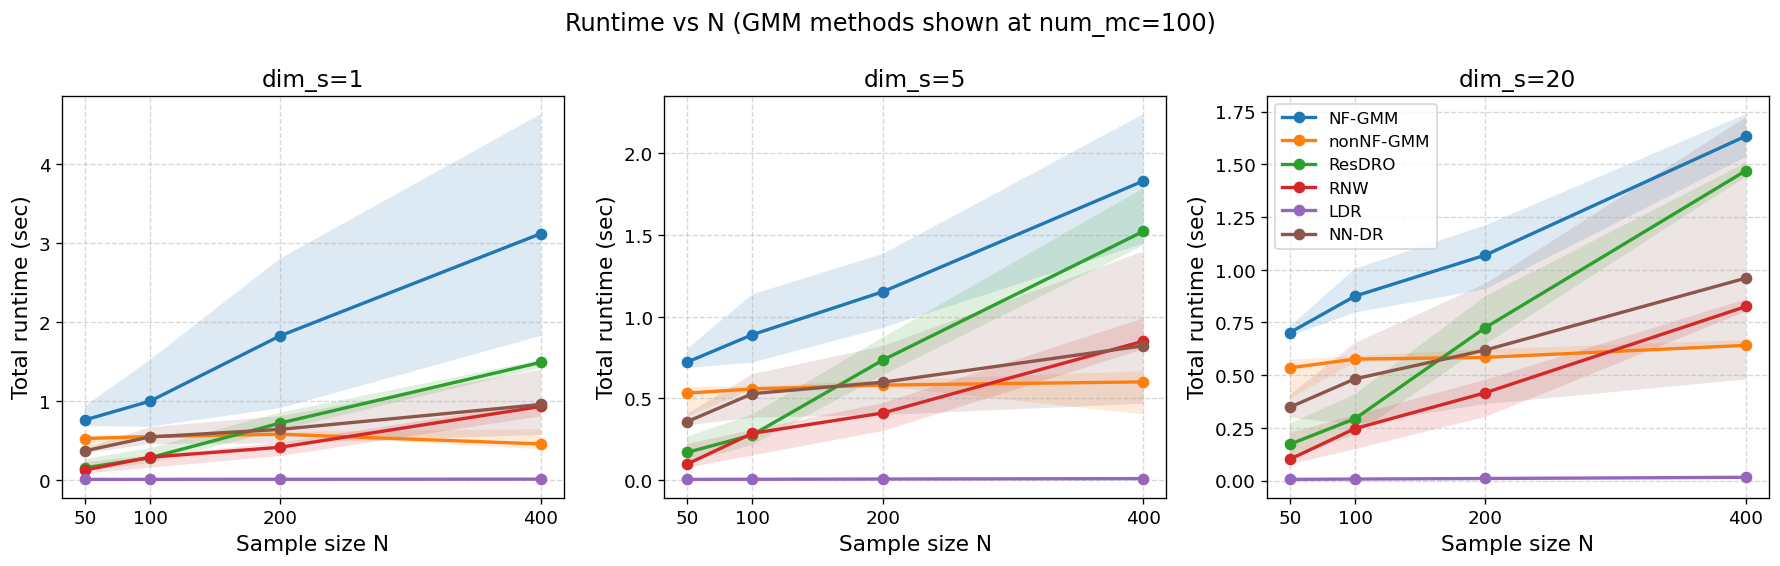


Saved Runtime vs N table to: Results/NV_runtime_vs_N.csv
GMM methods are reported at num_mc=100.
Each entry is avg runtime (10th percentile, 90th percentile), rounded to 3 decimals.


method,dim_s,N,NF-GMM,nonNF-GMM,ResDRO,RNW,LDR,NN-DR
0,1,50,"0.757 (0.679, 0.930)","0.522 (0.383, 0.562)","0.150 (0.106, 0.265)","0.122 (0.076, 0.223)","0.005 (0.004, 0.005)","0.365 (0.331, 0.395)"
1,1,100,"0.995 (0.672, 1.519)","0.547 (0.541, 0.565)","0.279 (0.213, 0.400)","0.285 (0.153, 0.307)","0.005 (0.005, 0.005)","0.542 (0.451, 0.666)"
2,1,200,"1.824 (0.907, 2.803)","0.576 (0.564, 0.606)","0.718 (0.630, 0.852)","0.411 (0.301, 0.468)","0.006 (0.006, 0.006)","0.638 (0.461, 0.806)"
3,1,400,"3.118 (1.823, 4.631)","0.454 (0.386, 0.640)","1.487 (1.418, 1.519)","0.929 (0.803, 0.982)","0.007 (0.007, 0.008)","0.953 (0.568, 1.394)"
4,5,50,"0.722 (0.685, 0.804)","0.533 (0.391, 0.571)","0.170 (0.106, 0.267)","0.099 (0.076, 0.221)","0.005 (0.005, 0.005)","0.358 (0.336, 0.405)"
5,5,100,"0.890 (0.719, 1.136)","0.558 (0.553, 0.573)","0.277 (0.215, 0.403)","0.286 (0.152, 0.308)","0.005 (0.005, 0.006)","0.529 (0.382, 0.649)"
6,5,200,"1.152 (0.931, 1.384)","0.581 (0.574, 0.610)","0.734 (0.642, 0.873)","0.411 (0.300, 0.471)","0.007 (0.007, 0.007)","0.599 (0.398, 0.820)"
7,5,400,"1.830 (1.447, 2.239)","0.601 (0.402, 0.666)","1.522 (1.436, 1.786)","0.850 (0.800, 0.990)","0.010 (0.009, 0.010)","0.822 (0.468, 1.399)"
8,20,50,"0.701 (0.686, 0.731)","0.534 (0.389, 0.573)","0.172 (0.106, 0.271)","0.101 (0.076, 0.226)","0.005 (0.005, 0.006)","0.348 (0.298, 0.405)"
9,20,100,"0.874 (0.797, 1.004)","0.576 (0.561, 0.591)","0.293 (0.217, 0.410)","0.246 (0.149, 0.310)","0.007 (0.007, 0.007)","0.482 (0.266, 0.652)"


In [3]:
base_dir = Path("Results")
runtime_summary_path = base_dir / "NV_run_time.csv"

method_order_runtime = [
    "NF-GMM",
    "nonNF-GMM",
    "ResDRO",
    "RNW",
    "LDR",
    "NN-DR",
]

runtime_label_map = {
    "Non-NF-GMM": "nonNF-GMM",
    "nonNF-GMM": "nonNF-GMM",
    "NF-GMM": "NF-GMM",
    "ResDRO": "ResDRO",
    "RNW": "RNW",
    "LDR": "LDR",
    "NN-DR": "NN-DR",
}

required_summary_cols = {
    "dim_s",
    "N",
    "num_mc",
    "method",
    "avg_total_time_sec",
    "p10_total_time_sec",
    "p90_total_time_sec",
    "std_total_time_sec",
    "avg_fit_time_sec",
    "p10_fit_time_sec",
    "p90_fit_time_sec",
    "avg_sampling_decision_time_sec",
    "p10_sampling_decision_time_sec",
    "p90_sampling_decision_time_sec",
    "n_success",
}

if not runtime_summary_path.exists():
    raise FileNotFoundError(f"Missing runtime summary file: {runtime_summary_path}")

runtime_summary = pd.read_csv(runtime_summary_path)

missing_cols = sorted(required_summary_cols - set(runtime_summary.columns))
if missing_cols:
    raise ValueError(
        "run_time.csv does not match the required running-time schema. "
        f"Missing columns: {missing_cols}"
    )

runtime_summary["method"] = runtime_summary["method"].map(
    lambda x: runtime_label_map.get(x, x)
)

dim_values = sorted(runtime_summary["dim_s"].dropna().unique())

method_order_present = [
    method for method in method_order_runtime
    if method in set(runtime_summary["method"])
]

def make_avg_p10_p90_string(df, avg_col, p10_col, p90_col):
    return df.apply(
        lambda r: f"{r[avg_col]:.3f} ({r[p10_col]:.3f}, {r[p90_col]:.3f})",
        axis=1,
    )

overview_num_mc = 100

gmm_mask = runtime_summary["method"].isin(["NF-GMM", "nonNF-GMM"])

gmm_overview = runtime_summary[
    gmm_mask
    & runtime_summary["num_mc"].notna()
    & np.isclose(runtime_summary["num_mc"], overview_num_mc)
].copy()

if len(gmm_overview) == 0:
    available_num_mc = sorted(
        runtime_summary.loc[gmm_mask, "num_mc"]
        .dropna()
        .unique()
    )

    if len(available_num_mc) == 0:
        raise ValueError("No num_mc values found for GMM methods.")

    overview_num_mc = int(available_num_mc[0])

    gmm_overview = runtime_summary[
        gmm_mask
        & runtime_summary["num_mc"].notna()
        & np.isclose(runtime_summary["num_mc"], overview_num_mc)
    ].copy()

non_gmm_overview = runtime_summary[~gmm_mask].copy()

overview_df = pd.concat(
    [non_gmm_overview, gmm_overview],
    ignore_index=True,
)

fig, axes = plt.subplots(
    1,
    len(dim_values),
    figsize=(max(6, 5 * len(dim_values)), 4.8),
    sharey=False,
    squeeze=False,
)

axes = axes.ravel()

for ax, dim_value in zip(axes, dim_values):
    dim_df = overview_df[overview_df["dim_s"] == dim_value].copy()

    for method in method_order_present:
        temp = dim_df[dim_df["method"] == method].sort_values("N")

        if len(temp) == 0:
            continue

        ax.plot(
            temp["N"].values,
            temp["avg_total_time_sec"].values,
            marker="o",
            linewidth=2,
            label=method,
        )

        ax.fill_between(
            temp["N"].values,
            temp["p10_total_time_sec"].values,
            temp["p90_total_time_sec"].values,
            alpha=0.15,
        )

    ax.set_title(f"dim_s={int(dim_value)}")
    ax.set_xlabel("Sample size N")
    ax.set_ylabel("Total runtime (sec)")
    ax.set_xticks(sorted(dim_df["N"].dropna().unique()))
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].legend(ncol=1, frameon=True, loc="best")

fig.suptitle(f"Runtime vs N (GMM methods shown at num_mc={overview_num_mc})")
fig.tight_layout()
plt.show()

overview_table = overview_df.copy()

overview_table["Runtime avg (p10, p90)"] = make_avg_p10_p90_string(
    overview_table,
    "avg_total_time_sec",
    "p10_total_time_sec",
    "p90_total_time_sec",
)

table_runtime_vs_N = overview_table.pivot_table(
    index=["dim_s", "N"],
    columns="method",
    values="Runtime avg (p10, p90)",
    aggfunc="first",
)

ordered_cols = [
    method for method in method_order_runtime
    if method in table_runtime_vs_N.columns
]

table_runtime_vs_N = table_runtime_vs_N[ordered_cols].reset_index()

table_runtime_vs_N["dim_s"] = table_runtime_vs_N["dim_s"].astype(int)
table_runtime_vs_N["N"] = table_runtime_vs_N["N"].astype(int)

table_runtime_vs_N = table_runtime_vs_N.sort_values(
    ["dim_s", "N"]
).reset_index(drop=True)

table_runtime_vs_N_path = base_dir / "NV_runtime_vs_N.csv"
table_runtime_vs_N.to_csv(table_runtime_vs_N_path, index=False)

print(f"\nSaved Runtime vs N table to: {table_runtime_vs_N_path}")
print(f"GMM methods are reported at num_mc={overview_num_mc}.")
print("Each entry is avg runtime (10th percentile, 90th percentile), rounded to 3 decimals.")

display(table_runtime_vs_N)